In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [39]:
data= pd.read_csv(r"C:\Users\91739\Downloads\amazon.csv",encoding="iso-8859-1", parse_dates=['date'])
print("Dataset Shape:", df.shape)

Dataset Shape: (6454, 5)


In [40]:
print("Number of Rows", data.shape[0])
print("Number of Columns", data.shape[1])

Number of Rows 6454
Number of Columns 5


In [41]:
data.dtypes

year               int64
state                str
month                str
number           float64
date      datetime64[us]
dtype: object

In [42]:
### check first 5 rows in dataset
data.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [43]:
### check last 5 rows in dataset
data.tail()

,year,state,month,number,date
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01
6453,2016,Tocantins,Dezembro,119.0,2016-01-01


In [44]:
### Getting Information About Our Dataset:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    6454 non-null   int64         
 1   state   6454 non-null   str           
 2   month   6454 non-null   str           
 3   number  6454 non-null   float64       
 4   date    6454 non-null   datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 252.2 KB


In [45]:
### Check Null Values In The Dataset:
print(data.isnull().sum())

year      0
state     0
month     0
number    0
date      0
dtype: int64


In [46]:
### Check For Duplicate Data and Drop Them:
print("Total Duplicate Rows:", data.duplicated().sum())
data = data.drop_duplicates()
print("Shape After Removing Duplicates:", data.shape)

Total Duplicate Rows: 32
Shape After Removing Duplicates: (6422, 5)


In [47]:
### Get Overall Statistics About The DataFrame:
data.describe(include='all')

,year,state,month,number,date
count,6422.000000,6422,6422,6422.000000,6422
unique,NaN,23,12,NaN,NaN
top,NaN,Rio,Agosto,NaN,NaN
freq,NaN,697,540,NaN,NaN
mean,2007.490969,NaN,NaN,108.815178,2007-06-29 10:46:40.622859
min,1998.000000,NaN,NaN,0.000000,1998-01-01 00:00:00
25%,2003.000000,NaN,NaN,3.000000,2003-01-01 00:00:00
50%,2007.000000,NaN,NaN,24.497000,2007-01-01 00:00:00
75%,2012.000000,NaN,NaN,114.000000,2012-01-01 00:00:00
max,2017.000000,NaN,NaN,998.000000,2017-01-01 00:00:00


In [48]:
### Rename Month Names To English:
data['month'] = data['month'].replace({'Janeiro': 'January','Fevereiro': 'February','Março': 'March','Abril': 'April','Maio': 'May','Junho': 'June','Julho': 'July','Agosto': 'August','Setembro': 'September','Outubro': 'October','Novembro': 'November','Dezembro': 'December'})
data['month'].unique()

<StringArray>
[  'January',  'February',     'March',     'April',       'May',      'June',
      'July',    'August', 'September',   'October',  'November',  'December']
Length: 12, dtype: str

In [49]:
### Find Total Number of Fires Registered:
print("Total Number of Fires Registered:",data['number'].sum())

Total Number of Fires Registered: 698811.073


In [50]:
### In Which Month Maximum Number of Forest Fires Were Reported:
data.groupby('month')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

month
July    92319.113
Name: number, dtype: float64

In [51]:
### In Which Year Maximum Number of Forest Fires Was Reported:
data.groupby('year')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

year
2003    42760.674
Name: number, dtype: float64

In [52]:
### In Which State Maximum Number of Forest Fires Was Reported:
data.groupby('state')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

state
Mato Grosso    96246.028
Name: number, dtype: float64

In [53]:
### Find Total Number of Fires Were Reported In Amazonas:
amazonas = data[data['state'] == 'Amazonas']
print("Total Fires Reported In Amazonas:",amazonas['number'].sum())

Total Fires Reported In Amazonas: 30650.129


In [54]:
### Display Number of Fires Were Reported In Amazonas (Year-Wise):
amazonas.groupby('year')['number']\
         .sum()\
         .reset_index()

,year,number
0,1998,946.000
1,1999,1061.000
2,2000,853.000
3,2001,1297.000
4,2002,2852.000
5,2003,1524.268
6,2004,2298.207
7,2005,1657.128
8,2006,997.640
9,2007,589.601


In [55]:
###  Find Total Number of Fires Were Reported In 2016 And Visualize Data Based on Each Month:
fire_2016 = data[data['year'] == 2016]

monthly_fire = fire_2016.groupby('month')['number']\
                         .sum()\
                         .reset_index()
monthly_fire

,month,number
0,April,2203.770
1,August,3137.215
2,December,3740.877
3,February,3098.050
4,January,2906.076
5,July,7105.048
6,June,3776.565
7,March,1632.166
8,May,2488.081
9,November,4692.476


In [56]:
###  Display Number of Fires Were Reported In Amazonas (Day-Wise):
data['date'] = pd.to_datetime(data['date'])
amazonas = data[data['state'] == 'Amazonas']
amazonas.groupby(amazonas['date'].dt.dayofweek)['number']\
         .sum()\
         .reset_index(name='Number_of_Fires')

,date,Number_of_Fires
0,0,1886.601
1,1,6474.217
2,2,3910.177
3,3,5754.802
4,4,5446.480
5,5,4162.666
6,6,3015.186


In [57]:
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}
amazonas.groupby(amazonas['date'].dt.dayofweek)['number']\
         .sum()\
         .rename(index=day_names)

date
Monday       1886.601
Tuesday      6474.217
Wednesday    3910.177
Thursday     5754.802
Friday       5446.480
Saturday     4162.666
Sunday       3015.186
Name: number, dtype: float64

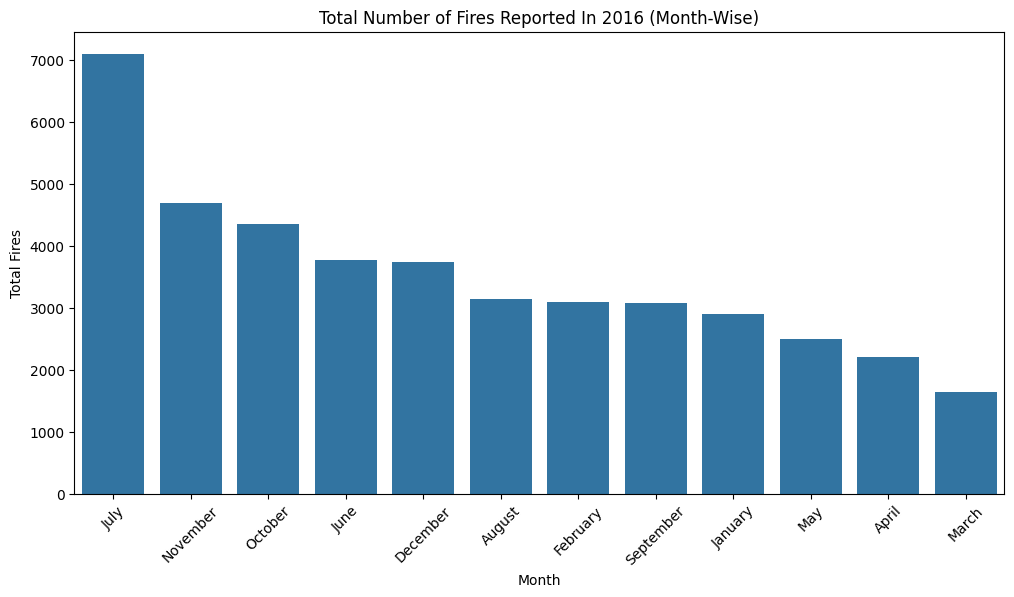

In [58]:
plt.figure(figsize=(12,6))

sns.barplot(x='month',y='number',data=monthly_fire,order=monthly_fire.sort_values('number',ascending=False)['month'])
plt.xticks(rotation=45)
plt.title('Total Number of Fires Reported In 2016 (Month-Wise)')
plt.xlabel('Month')
plt.ylabel('Total Fires')
plt.show()

In [59]:
### Find Average Number of Fires Were Reported From Highest to Lowest (State-Wise):
data.groupby('state')['number']\
    .mean()\
    .sort_values(ascending=False)\
    .reset_index(name='Average_Number_of_Fires')

,state,Average_Number_of_Fires
0,Sao Paulo,213.896226
1,Mato Grosso,203.479975
2,Bahia,187.222703
3,Piau,158.174674
4,Goias,157.721841
5,Minas Gerais,156.800243
6,Tocantins,141.037176
7,Amazonas,128.243218
8,Ceara,127.314071
9,Paraiba,111.073979


In [60]:
### Find The State Names Where Fires Were Reported In june Month:
data[data['month'] == 'June']['state']\
    .drop_duplicates()\
    .reset_index(drop=True)

0                 Acre
1              Alagoas
2                Amapa
3             Amazonas
4                Bahia
5                Ceara
6     Distrito Federal
7       Espirito Santo
8                Goias
9             Maranhao
10         Mato Grosso
11        Minas Gerais
12                Pará
13             Paraiba
14          Pernambuco
15                Piau
16                 Rio
17            Rondonia
18             Roraima
19      Santa Catarina
20           Sao Paulo
21             Sergipe
22           Tocantins
Name: state, dtype: str